# Baseline CNN for Wefabricate

Simple VGG-style CNN to classify front-plate images as ok or ng.
Trains on 136 images, tests on 34.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# support.py uses relative paths, so cd into its folder
%cd "WF-data and support code"

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)

/Users/mihnea/_workspace_/_uni/_master/dmai/DMAI_assignment_2/WF-data and support code
device: mps


In [2]:
from support import load_dataset

train_dataset, test_dataset = load_dataset()
print("train:", len(train_dataset), "test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

train: 136 test: 34


In [3]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # block 1: 3 -> 32, two 3x3 convs + pool
        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # block 2: 32 -> 64
        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.relu = nn.ReLU()
        # fc head: 60x30 input -> 15x7 after two pools -> 64*15*7 = 6720
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 15 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.relu(self.conv1a(x))
        x = self.relu(self.conv1b(x))
        x = self.pool(x)
        x = self.relu(self.conv2a(x))
        x = self.relu(self.conv2b(x))
        x = self.pool(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

In [5]:
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(dim=1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

In [6]:
def save_weights(model, path):
    torch.save(model.state_dict(), path)

def load_weights(model, path):
    model.load_state_dict(torch.load(path, map_location=device))
    return model

In [7]:
torch.manual_seed(42)

model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 30
train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(epochs):
    tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
    el, ea = evaluate(model, test_loader, criterion, device)
    train_loss_history.append(tl)
    train_acc_history.append(ta)
    test_loss_history.append(el)
    test_acc_history.append(ea)
    print(f"epoch {epoch+1:02d} | train loss {tl:.4f} acc {ta:.3f} | test loss {el:.4f} acc {ea:.3f}")

epoch 01 | train loss 0.6981 acc 0.478 | test loss 0.6947 acc 0.500


epoch 02 | train loss 0.6948 acc 0.500 | test loss 0.6934 acc 0.500


epoch 03 | train loss 0.6935 acc 0.493 | test loss 0.6933 acc 0.500


epoch 04 | train loss 0.6934 acc 0.478 | test loss 0.6930 acc 0.500


epoch 05 | train loss 0.6960 acc 0.463 | test loss 0.6935 acc 0.500


...

epoch 26 | train loss 0.1956 acc 0.919 | test loss 0.0620 acc 1.000


epoch 27 | train loss 0.1896 acc 0.919 | test loss 0.0964 acc 1.000


epoch 28 | train loss 0.1995 acc 0.934 | test loss 0.1772 acc 0.882


epoch 29 | train loss 0.1815 acc 0.949 | test loss 0.0827 acc 1.000


epoch 30 | train loss 0.1659 acc 0.956 | test loss 0.0550 acc 1.000


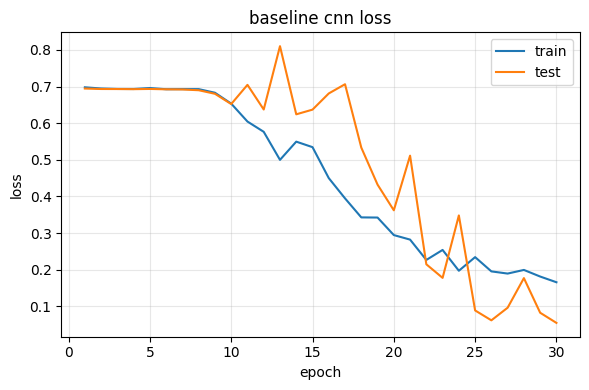

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_loss_history, label="train")
plt.plot(range(1, epochs + 1), test_loss_history, label="test")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("baseline cnn loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../loss_curve.pdf")
plt.show()

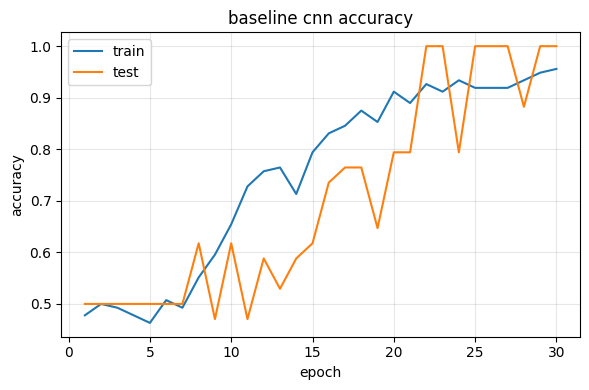

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_acc_history, label="train")
plt.plot(range(1, epochs + 1), test_acc_history, label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("baseline cnn accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../accuracy_curve.pdf")
plt.show()

In [10]:
print(f"final test accuracy: {test_acc_history[-1]:.3f}")
save_weights(model, "../model_before_tuning.pth")
print("weights saved to model_before_tuning.pth")

final test accuracy: 1.000
weights saved to model_before_tuning.pth
